# Retail Sales and Profit Analysis

This project explores how discounts affect sales and profit using the Superstore dataset.

The goal is to better understand pricing patterns and use machine learning models to predict sales and profit. A main focus of this project is seeing whether discounts actually help the business or hurt profitability.

# Imports.

In [1]:
# Import libraries needed for data analysis, visualization, and machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Load.

In [2]:
# Load the Superstore dataset into a pandas dataframe.

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Initial Exploration.

In [3]:
# Quick look at the dataset to understand the columns and overall structure.

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Data Overview.

The dataset includes retail transaction information such as sales, profit, discount, quantity, category, and order date.

There are no missing values in the dataset, which means the data is already in good shape for analysis and modeling.

# Correlation.

In [7]:
# Check how key numeric variables relate to each other.

df[["Sales", "Profit", "Quantity", "Discount"]].corr()

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479064,0.200795,-0.028190
Profit,0.479064,1.000000,0.066253,-0.219487
Quantity,0.200795,0.066253,1.000000,0.008623
Discount,-0.028190,-0.219487,0.008623,1.000000


## Correlation Analysis.

The correlation results show that discount has a negative relationship with profit.

This means that as discounts increase, profit tends to decrease. This is an early sign that heavy discounting may not be a good strategy if the goal is to protect profitability.

# Date Cleaning.

In [8]:
# Convert order date to datetime so it can be used for time-based analysis.

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df.dropna(subset=["Order Date"])

print("Total rows:", len(df))
print("Rows with valid dates:", df["Order Date"].notnull().sum())
print(df["Order Date"].dtype)
print(df["Order Date"].head())

Total rows: 9994
Rows with valid dates: 9994
datetime64[ns]
0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[ns]


## Date Preparation.

The order date column was converted to datetime format so the data could be used for monthly trend analysis and feature engineering.

All rows remained valid after conversion, so no records were lost in this step.

# Sales by Category.

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


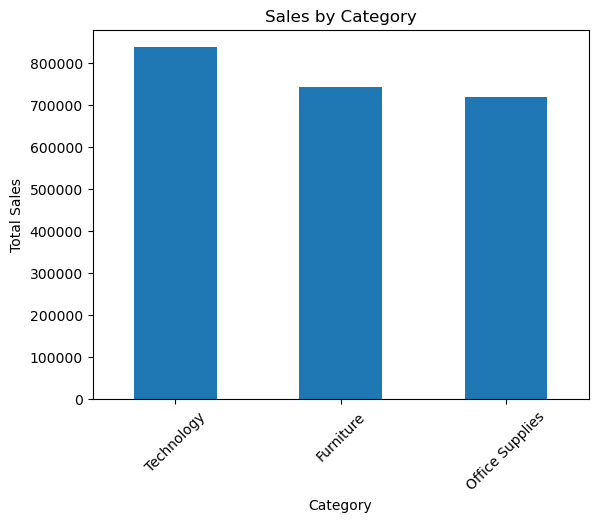

In [9]:
# Group data by category to see which categories generate the most sales.

sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(sales_by_category)

sales_by_category.plot(kind="bar")
plt.ylabel("Total Sales")
plt.title("Sales by Category")
plt.xticks(rotation=45)
plt.show()

## Sales by Category.

Technology has the highest sales, followed by furniture and office supplies.

This suggests that some product categories contribute more to revenue than others.

# Top Sub-Categories.

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64


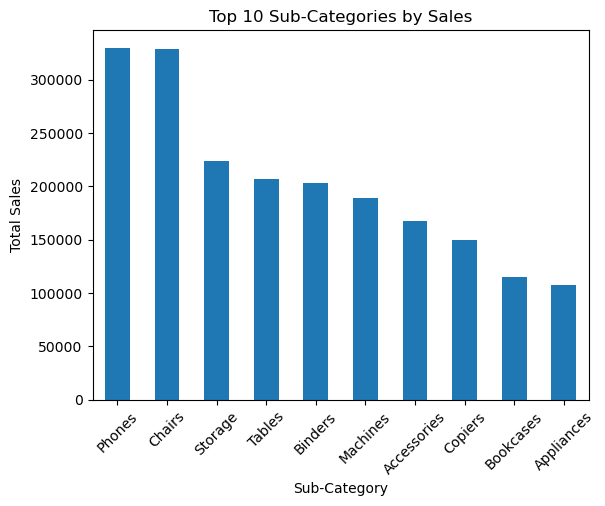

In [10]:
# Identify the top 10 sub-categories contributing the most to overall sales.

sales_by_subcategory = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
print(sales_by_subcategory.head(10))

sales_by_subcategory.head(10).plot(kind="bar")
plt.ylabel("Total Sales")
plt.title("Top 10 Sub-Categories by Sales")
plt.xticks(rotation=45)
plt.show()

## Top Sub-Categories by Sales.

Phones and chairs are the top-performing sub-categories in terms of sales.

This shows that certain products play a bigger role in overall revenue and may deserve more business attention.

# Average Sales by Discount.

Discount
0.60     48.150000
0.80     56.545853
0.70     97.177708
0.20    209.076940
0.00    226.742074
0.30    454.742974
0.45    498.634000
0.15    529.971567
0.32    536.794770
0.40    565.134874
0.10    578.397351
0.50    892.705152
Name: Sales, dtype: float64


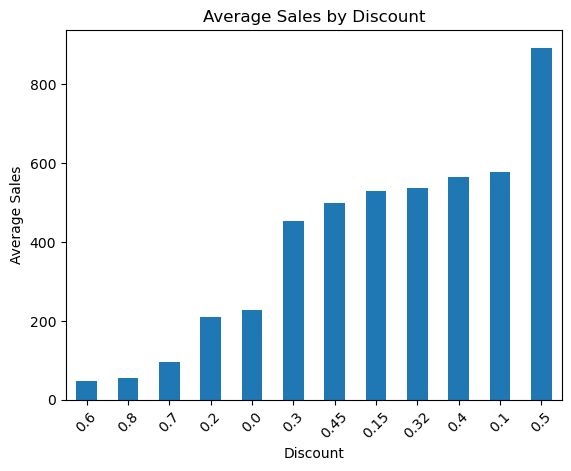

In [11]:
# Check how average sales change across different discount levels.

discount_sales = df.groupby("Discount")["Sales"].mean().sort_values()
print(discount_sales)

discount_sales.plot(kind="bar")
plt.ylabel("Average Sales")
plt.title("Average Sales by Discount")
plt.xticks(rotation=45)
plt.show()

## Average Sales by Discount.

Average sales do change across discount levels, but the pattern is not completely consistent.

This suggests that discounts do not always guarantee stronger sales performance.

# Average Profit by Discount.

Discount
0.50   -310.703456
0.45   -226.646464
0.40   -111.927429
0.80   -101.796797
0.70    -95.874060
0.32    -88.560656
0.30    -45.679636
0.60    -43.077212
0.20     24.702572
0.15     27.288298
0.00     66.900292
0.10     96.055074
Name: Profit, dtype: float64


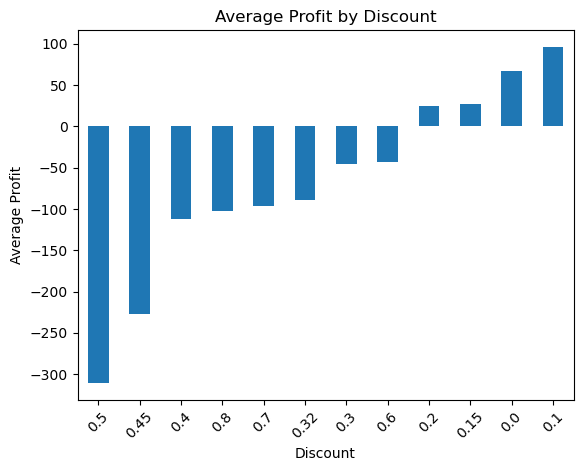

In [12]:
# Analyze how profit is affected as discount increases.

discount_profit = df.groupby("Discount")["Profit"].mean().sort_values()
print(discount_profit)

discount_profit.plot(kind="bar")
plt.ylabel("Average Profit")
plt.title("Average Profit by Discount")
plt.xticks(rotation=45)
plt.show()

## Average Profit by Discount.

Higher discounts are clearly linked to lower profits.

At higher discount levels, average profit becomes negative. This means discounts may help in some situations, but large discounts can hurt profitability.

# Scatter Plot.

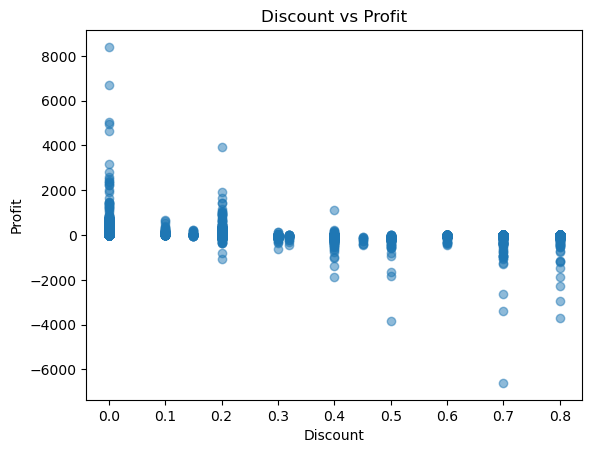

In [13]:
# Visualize the relationship between discount and profit to spot patterns.

plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

## Discount vs Profit

The scatter plot reinforces the same pattern seen earlier.

As discount increases, profit generally moves downward. Heavy discounting appears to be risky from a profitability point of view.

# Monthly Trend.

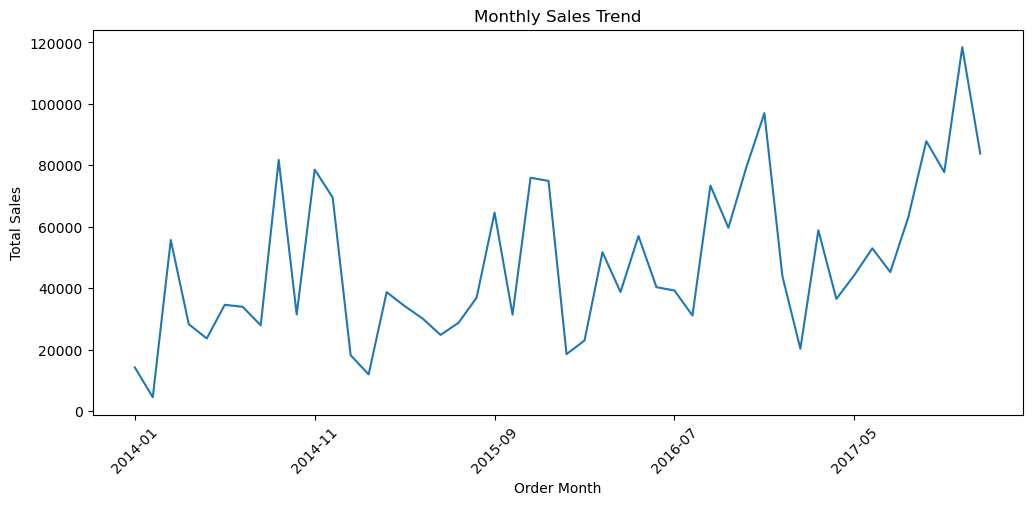

In [14]:
# Group sales by month to identify trends and possible seasonality.

df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Order Month")["Sales"].sum()

monthly_sales.plot(figsize=(12, 5))
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

## Monthly Sales Trend.

Sales fluctuate over time, which suggests that timing may influence performance.

This may point to seasonal patterns, although more business context would be needed to confirm that fully.

# Regional Analysis.

In [15]:
# Check how many regions are in the dataset and how records are distributed across them.

print("Number of regions:", df["Region"].nunique())
print("Region names:", df["Region"].unique())
print(df["Region"].value_counts())

Number of regions: 4
Region names: ['South' 'West' 'Central' 'East']
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


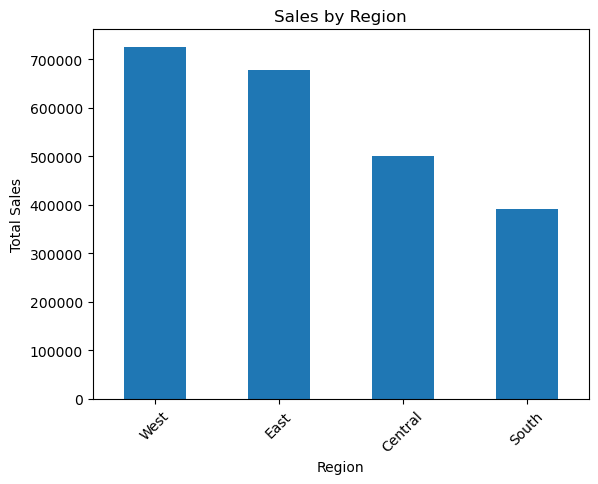

In [16]:
# Compare total sales across regions to see geographic performance differences.

sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(sales_by_region)

sales_by_region.plot(kind="bar")
plt.ylabel("Total Sales")
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.show()

## Sales by Region

The West region has the highest sales, followed by East, Central, and South.

This shows that geographic region also seems to play a role in sales performance.

# Feature Engineering.

In [17]:
# Create new features to help the models capture time patterns and discount behavior.

df["Month"] = df["Order Date"].dt.month
df["Year"] = df["Order Date"].dt.year
df["DayOfWeek"] = df["Order Date"].dt.dayofweek
df["High_Discount"] = (df["Discount"] > 0.2).astype(int)

df[["Order Date", "Month", "Year", "DayOfWeek", "Discount", "High_Discount"]].head()

,Order Date,Month,Year,DayOfWeek,Discount,High_Discount
0,2016-11-08,11,2016,1,0.00,0
1,2016-11-08,11,2016,1,0.00,0
2,2016-06-12,6,2016,6,0.00,0
3,2015-10-11,10,2015,6,0.45,1
4,2015-10-11,10,2015,6,0.20,0


## Feature Engineering.

New features were created from the order date and discount columns.

These features help the models capture time-based patterns and separate higher-discount orders from lower-discount ones.

# High vs. Low Discount profit.

In [18]:
# Compare average profit between high-discount and low-discount orders

df.groupby("High_Discount")["Profit"].mean()

High_Discount
0    49.037679
1   -97.183098
Name: Profit, dtype: float64

## High vs. Low Discount Profit.

Orders with higher discounts have negative average profit, while lower-discount orders remain profitable on average.

This supports the idea that discounts above 20% should be used carefully.

# Data Leakage Note.

The first sales model includes profit as a predictor.

That setup creates data leakage because profit is closely tied to sales. I kept this version for comparison only, but it is not the model I would treat as realistic.

# Model 1: Sales with Profit Leakage.

In [19]:
# Define the target and predictors for the sales model that includes profit.
# This version is only for comparison because it contains data leakage.

y_sales_leak = df["Sales"]
X_sales_leak = df[[
    "Quantity", "Discount", "Profit",
    "Month", "Year", "DayOfWeek", "High_Discount",
    "Category", "Sub-Category", "Region", "Segment", "Ship Mode"
]]

X_sales_leak = pd.get_dummies(X_sales_leak, drop_first=True)

In [20]:
# Split the leakage model data into training and testing sets.

X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_sales_leak, y_sales_leak, test_size=0.2, random_state=42
)

In [21]:
# Train and evaluate Linear Regression for the leakage model.

lr_leak = LinearRegression()
lr_leak.fit(X_train_leak, y_train_leak)
y_pred_lr_leak = lr_leak.predict(X_test_leak)

lr_leak_mae = mean_absolute_error(y_test_leak, y_pred_lr_leak)
lr_leak_rmse = np.sqrt(mean_squared_error(y_test_leak, y_pred_lr_leak))
lr_leak_r2 = r2_score(y_test_leak, y_pred_lr_leak)

print("Leakage Model - Linear Regression MAE:", lr_leak_mae)
print("Leakage Model - Linear Regression RMSE:", lr_leak_rmse)
print("Leakage Model - Linear Regression R^2:", lr_leak_r2)

Leakage Model - Linear Regression MAE: 198.82739322128896
Leakage Model - Linear Regression RMSE: 753.3492601566077
Leakage Model - Linear Regression R^2: 0.03921464001635522


In [22]:
# Train and evaluate Random Forest model for the leakage model.

rf_leak = RandomForestRegressor(random_state=42, n_estimators=100)
rf_leak.fit(X_train_leak, y_train_leak)
y_pred_rf_leak = rf_leak.predict(X_test_leak)

rf_leak_mae = mean_absolute_error(y_test_leak, y_pred_rf_leak)
rf_leak_rmse = np.sqrt(mean_squared_error(y_test_leak, y_pred_rf_leak))
rf_leak_r2 = r2_score(y_test_leak, y_pred_rf_leak)

print("Leakage Model - Random Forest MAE:", rf_leak_mae)
print("Leakage Model - Random Forest RMSE:", rf_leak_rmse)
print("Leakage Model - Random Forest R^2:", rf_leak_r2)

Leakage Model - Random Forest MAE: 84.4845839809905
Leakage Model - Random Forest RMSE: 487.92141669519094
Leakage Model - Random Forest R^2: 0.5969736815962479


In [23]:
# Display the strongest positive and negative coefficients from the linear Regression model.

coefficients_leak = pd.DataFrame({
    "Feature": X_sales_leak.columns,
    "Coefficient": lr_leak.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients_leak.head(10)

,Feature,Coefficient
19,Sub-Category_Machines,987.986589
14,Sub-Category_Copiers,971.343546
24,Sub-Category_Tables,338.208134
12,Sub-Category_Bookcases,187.184236
21,Sub-Category_Phones,151.096769
22,Sub-Category_Storage,125.436939
23,Sub-Category_Supplies,116.194558
13,Sub-Category_Chairs,113.875448
9,Sub-Category_Appliances,59.498466
1,Discount,58.957777


In [24]:
coefficients_leak.tail(10)

,Feature,Coefficient
30,Ship Mode_Same Day,-15.194272
11,Sub-Category_Binders,-43.514173
15,Sub-Category_Envelopes,-78.674378
20,Sub-Category_Paper,-86.559869
10,Sub-Category_Art,-86.998597
18,Sub-Category_Labels,-94.422332
16,Sub-Category_Fasteners,-118.262985
8,Category_Technology,-180.734158
7,Category_Office Supplies,-207.302371
17,Sub-Category_Furnishings,-251.231289


## Leakage Model Results.

The Linear Regression coefficients show which features have the strongest impact on sales.

Positive coefficients indicate features that increase sales, while negative coefficients indicate features that decrease sales.

Since this model includes profit as a predictor, the results are affected by data leakage and should not be fully trusted.

# Model 2: Realistic Sales Model Without Profit.

In [25]:
# Define target and predictors for sales model without Profit.

y_sales = df["Sales"]

X_sales = df[[
    "Quantity", "Discount",
    "Month", "Year", "DayOfWeek", "High_Discount",
    "Category", "Sub-Category", "Region", "Segment", "Ship Mode"
]]

X_sales = pd.get_dummies(X_sales, drop_first=True)

In [26]:
# Split the realistic sales model data into training and testing sets.

X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(
    X_sales, y_sales, test_size=0.2, random_state=42
)

In [27]:
# Train and evaluate Linear Regression for sales prediction.

lr_sales = LinearRegression()
lr_sales.fit(X_train_sales, y_train_sales)
y_pred_lr_sales = lr_sales.predict(X_test_sales)

lr_sales_mae = mean_absolute_error(y_test_sales, y_pred_lr_sales)
lr_sales_rmse = np.sqrt(mean_squared_error(y_test_sales, y_pred_lr_sales))
lr_sales_r2 = r2_score(y_test_sales, y_pred_lr_sales)

print("Sales Model - Linear Regression MAE:", lr_sales_mae)
print("Sales Model - Linear Regression RMSE:", lr_sales_rmse)
print("Sales Model - Linear Regression R^2:", lr_sales_r2)

Sales Model - Linear Regression MAE: 226.78834710989932
Sales Model - Linear Regression RMSE: 693.686587128384
Sales Model - Linear Regression R^2: 0.18537030105806773


In [28]:
# Train and evaluate Random Forest for sales prediction.

rf_sales = RandomForestRegressor(random_state=42, n_estimators=100)
rf_sales.fit(X_train_sales, y_train_sales)
y_pred_rf_sales = rf_sales.predict(X_test_sales)

rf_sales_mae = mean_absolute_error(y_test_sales, y_pred_rf_sales)
rf_sales_rmse = np.sqrt(mean_squared_error(y_test_sales, y_pred_rf_sales))
rf_sales_r2 = r2_score(y_test_sales, y_pred_rf_sales)

print("Sales Model - Random Forest MAE:", rf_sales_mae)
print("Sales Model - Random Forest RMSE:", rf_sales_rmse)
print("Sales Model - Random Forest R^2:", rf_sales_r2)

Sales Model - Random Forest MAE: 212.08409068336547
Sales Model - Random Forest RMSE: 666.8381200131291
Sales Model - Random Forest R^2: 0.24720889024053327


In [29]:
# Display Linear Regression coefficients for the realistic sales model.

coefficients_sales = pd.DataFrame({
    "Feature": X_sales.columns,
    "Coefficient": lr_sales.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients_sales.head(10)

,Feature,Coefficient
13,Sub-Category_Copiers,2226.191450
18,Sub-Category_Machines,1187.596689
23,Sub-Category_Tables,327.513251
20,Sub-Category_Phones,181.573484
11,Sub-Category_Bookcases,178.382400
12,Sub-Category_Chairs,162.793864
8,Sub-Category_Appliances,111.848518
21,Sub-Category_Storage,110.565452
22,Sub-Category_Supplies,76.749459
10,Sub-Category_Binders,69.439547


In [30]:
coefficients_sales.tail(10)

,Feature,Coefficient
26,Region_West,-53.009301
14,Sub-Category_Envelopes,-86.494056
19,Sub-Category_Paper,-99.742808
9,Sub-Category_Art,-124.056796
17,Sub-Category_Labels,-124.299328
15,Sub-Category_Fasteners,-163.399159
7,Category_Technology,-174.923232
6,Category_Office Supplies,-229.389172
16,Sub-Category_Furnishings,-264.377110
1,Discount,-271.097272


## Coefficient Analysis (Realistic Sales Model)

The Linear Regression coefficients show which features have the strongest impact on sales.

Some features have a stronger influence than others, which helps explain how different factors contribute to predictions.

Since this model does not include profit, the results are more realistic compared to the leakage model.

## Sales Prediction Without Profit.

Once profit is removed, the model becomes more realistic.

Random Forest performs better than Linear Regression, which suggests that the relationships in the data are not purely linear. Still, the model performance is moderate, so there are likely missing factors that affect sales.

# Profit Prediction Model.

In [31]:
# Define target variable and predictor variables for profit prediction.

y_profit = df["Profit"]

X_profit = df[[
    "Quantity", "Discount",
    "Month", "Year", "DayOfWeek", "High_Discount",
    "Category", "Sub-Category", "Region", "Segment", "Ship Mode"
]]

X_profit = pd.get_dummies(X_profit, drop_first=True)

In [32]:
# Split the data into training and testing sets for the profit model.

X_train_profit, X_test_profit, y_train_profit, y_test_profit = train_test_split(
    X_profit, y_profit, test_size=0.2, random_state=42
)

In [33]:
# Train and evaluate Linear Regression for the profit model.

lr_profit = LinearRegression()
lr_profit.fit(X_train_profit, y_train_profit)
y_pred_lr_profit = lr_profit.predict(X_test_profit)

lr_profit_mae = mean_absolute_error(y_test_profit, y_pred_lr_profit)
lr_profit_rmse = np.sqrt(mean_squared_error(y_test_profit, y_pred_lr_profit))
lr_profit_r2 = r2_score(y_test_profit, y_pred_lr_profit)

print("Profit Model - Linear Regression MAE:", lr_profit_mae)
print("Profit Model - Linear Regression RMSE:", lr_profit_rmse)
print("Profit Model - Linear Regression R^2:", lr_profit_r2)

Profit Model - Linear Regression MAE: 70.45012529787451
Profit Model - Linear Regression RMSE: 211.26944269532382
Profit Model - Linear Regression R^2: 0.07941298049652934


In [34]:
# Train and evaluate Random Forest for the profit model.

rf_profit = RandomForestRegressor(random_state=42, n_estimators=100)
rf_profit.fit(X_train_profit, y_train_profit)
y_pred_rf_profit = rf_profit.predict(X_test_profit)

rf_profit_mae = mean_absolute_error(y_test_profit, y_pred_rf_profit)
rf_profit_rmse = np.sqrt(mean_squared_error(y_test_profit, y_pred_rf_profit))
rf_profit_r2 = r2_score(y_test_profit, y_pred_rf_profit)

print("Profit Model - Random Forest MAE:", rf_profit_mae)
print("Profit Model - Random Forest RMSE:", rf_profit_rmse)
print("Profit Model - Random Forest R^2:", rf_profit_r2)

Profit Model - Random Forest MAE: 69.0982377239852
Profit Model - Random Forest RMSE: 215.02541562340082
Profit Model - Random Forest R^2: 0.04638941044256162


In [35]:
# Display Linear Regression coefficients for the profit model.

coefficients_profit = pd.DataFrame({
    "Feature": X_profit.columns,
    "Coefficient": lr_profit.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients_profit.head(10)

,Feature,Coefficient
13,Sub-Category_Copiers,879.685577
18,Sub-Category_Machines,139.932597
10,Sub-Category_Binders,79.183906
8,Sub-Category_Appliances,36.698938
12,Sub-Category_Chairs,34.293260
20,Sub-Category_Phones,21.365081
0,Quantity,7.439909
29,Ship Mode_Same Day,4.179154
7,Category_Technology,4.073631
28,Segment_Home Office,2.885285


In [36]:
coefficients_profit.tail(10)

,Feature,Coefficient
6,Category_Office Supplies,-15.483503
24,Region_East,-17.925293
17,Sub-Category_Labels,-20.944659
25,Region_South,-21.273097
9,Sub-Category_Art,-25.978896
22,Sub-Category_Supplies,-27.652184
15,Sub-Category_Fasteners,-31.641795
26,Region_West,-32.706028
5,High_Discount,-73.658902
1,Discount,-231.378373


## Profit Prediction Results

The profit prediction models performed worse than the sales prediction models.

Both Linear Regression and Random Forest produced low R² values, indicating that the models explain very little of the variation in profit. Linear Regression achieved a slightly higher R², while Random Forest showed a slightly lower prediction error (MAE). Overall, neither model performed well.

This suggests that profit is more difficult to predict and is likely influenced by additional factors not included in the dataset, such as costs, business operations, or external variables.

# Compare Model Results.

In [37]:
results = pd.DataFrame({
    "Model": [
        "Sales With Profit - Linear Regression",
        "Sales With Profit - Random Forest",
        "Sales Without Profit - Linear Regression",
        "Sales Without Profit - Random Forest",
        "Profit Prediction - Linear Regression",
        "Profit Prediction - Random Forest"
    ],
    "MAE": [
        lr_leak_mae, rf_leak_mae,
        lr_sales_mae, rf_sales_mae,
        lr_profit_mae, rf_profit_mae
    ],
    "RMSE": [
        lr_leak_rmse, rf_leak_rmse,
        lr_sales_rmse, rf_sales_rmse,
        lr_profit_rmse, rf_profit_rmse
    ],
    "R^2": [
        lr_leak_r2, rf_leak_r2,
        lr_sales_r2, rf_sales_r2,
        lr_profit_r2, rf_profit_r2
    ]
})

results.sort_values(by="R^2", ascending=False)

,Model,MAE,RMSE,R^2
1,Sales With Profit - Random Forest,84.484584,487.921417,0.596974
3,Sales Without Profit - Random Forest,212.084091,666.838120,0.247209
2,Sales Without Profit - Linear Regression,226.788347,693.686587,0.185370
4,Profit Prediction - Linear Regression,70.450125,211.269443,0.079413
5,Profit Prediction - Random Forest,69.098238,215.025416,0.046389
0,Sales With Profit - Linear Regression,198.827393,753.349260,0.039215


## Model Comparison.

The best-performing model overall was the Random Forest model that used profit to predict sales, but that version contains data leakage.

Among the realistic models, Random Forest without profit performed best for sales prediction. Profit prediction was more difficult overall.

# Error Analysis.

In [38]:
# Review prediction errors for the realistic Random Forest sales model.

errors = pd.DataFrame({
    "Actual": y_test_sales,
    "Predicted": y_pred_rf_sales
})
errors["Error"] = errors["Actual"] - errors["Predicted"]
print(errors.describe())

             Actual    Predicted         Error
count   1999.000000  1999.000000   1999.000000
mean     246.735975   243.969182      2.766793
std      768.761867   359.798015    666.999234
min        0.836000     3.639560  -3056.801780
25%       17.250000    49.164660   -113.465667
50%       51.016000   115.425320    -32.086820
75%      200.889500   296.791396      8.838600
max    22638.480000  4556.751780  19392.223490


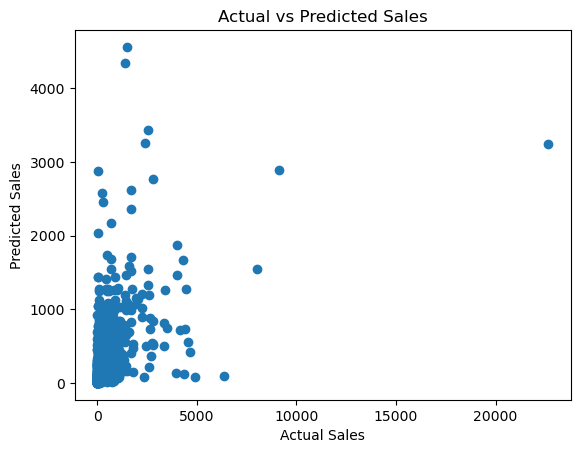

In [39]:
# Compare actual versus predicted sales values visually.

plt.scatter(y_test_sales, y_pred_rf_sales)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

## Error Analysis.

The model does capture some pattern in the data, but prediction errors are still fairly large.

This means the model can be useful for general guidance, but it is not strong enough for highly precise forecasting.

# Cross-Validation.

In [40]:
# Use cross-validation to check whether model performance stays consistent across different data splits.

cv_scores = cross_val_score(rf_sales, X_sales, y_sales, cv=5, scoring="r2")

print("Cross-validation R^2 scores:", cv_scores)
print("Average R^2:", cv_scores.mean())

Cross-validation R^2 scores: [-0.01438238  0.22098754 -0.05331755  0.16772172  0.22764725]
Average R^2: 0.10973131878659426


## Cross-Validation.

Cross-validation shows that model performance changes across different data splits.

This suggests that the model may not generalize strongly and should be used with caution.

# Feature Importance for Realistic Sales Model.

In [41]:
# Show which features matter most in the realistic Random Forest sales model.

feature_importance_sales = pd.DataFrame({
    "Feature": X_sales.columns,
    "Importance": rf_sales.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_sales.head(10)

,Feature,Importance
0,Quantity,0.188195
2,Month,0.148174
13,Sub-Category_Copiers,0.106176
4,DayOfWeek,0.094330
1,Discount,0.073989
3,Year,0.069620
18,Sub-Category_Machines,0.039770
27,Segment_Corporate,0.035378
6,Category_Office Supplies,0.033419
30,Ship Mode_Second Class,0.027870


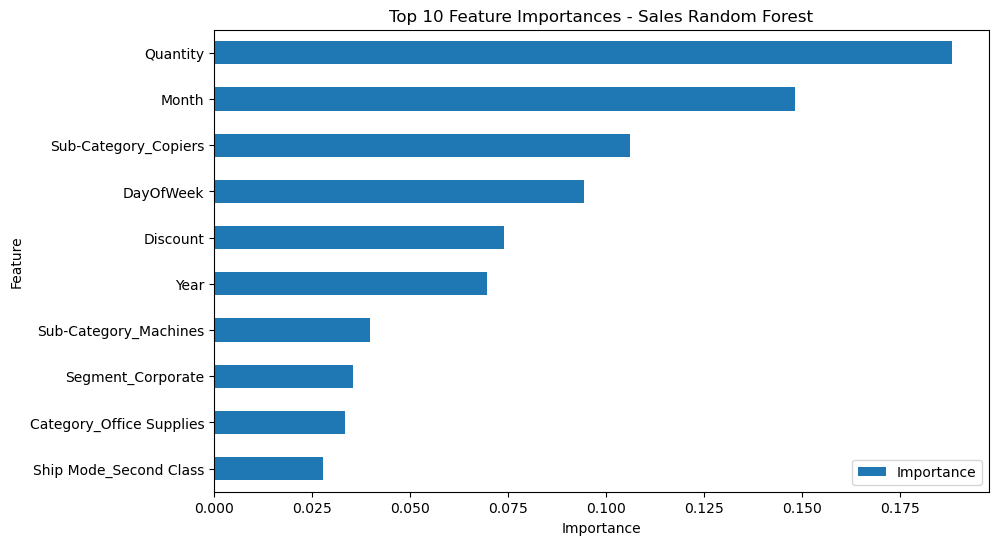

In [42]:
# Plot top feature importances for the realistic sales Random Forest model.

feature_importance_sales.head(10).sort_values(by="Importance").plot(
    kind="barh", x="Feature", y="Importance", figsize=(10, 6)
)
plt.title("Top 10 Feature Importances - Sales Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Feature Importance.

The most important features include quantity, discount, and time-related variables.

This suggests that both pricing and timing play a meaningful role in predicting sales and profit patterns.

# Profit Feature Importance.

In [43]:
# Show which features matter most in the Random Forest profit model.

feature_importance_profit = pd.DataFrame({
    "Feature": X_profit.columns,
    "Importance": rf_profit.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_profit.head(10)

,Feature,Importance
0,Quantity,0.176295
2,Month,0.134566
4,DayOfWeek,0.111972
13,Sub-Category_Copiers,0.103886
1,Discount,0.096503
3,Year,0.071042
27,Segment_Corporate,0.043932
18,Sub-Category_Machines,0.043444
24,Region_East,0.041101
28,Segment_Home Office,0.031444


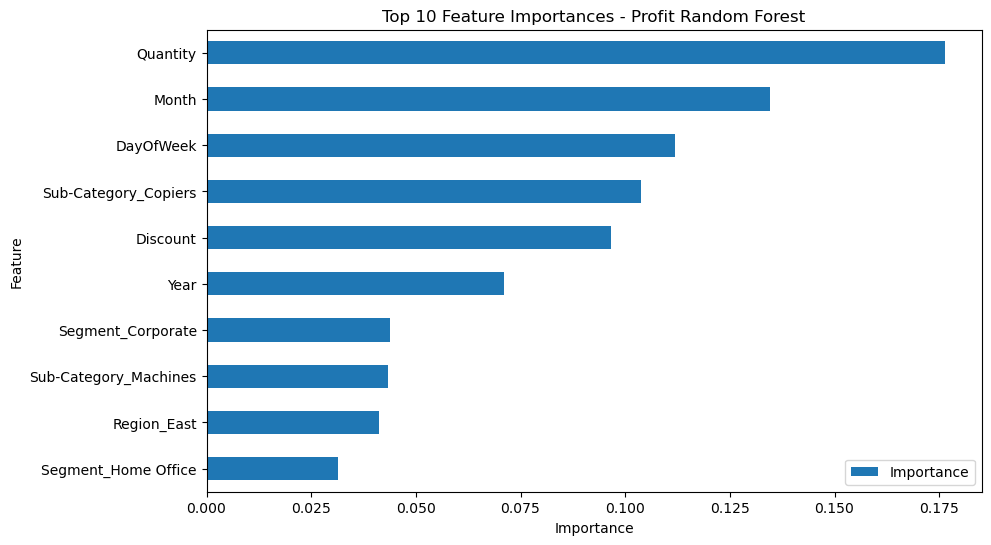

In [44]:
# Plot top feature importances for the profit Random Forest model.

feature_importance_profit.head(10).sort_values(by="Importance").plot(
    kind="barh", x="Feature", y="Importance", figsize=(10, 6)
)
plt.title("Top 10 Feature Importances - Profit Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Final Thoughts

This project shows that discounts can help sales in some cases, but they often reduce profit.

The machine learning results also show that more complex models like Random Forest perform better than Linear Regression, but performance is still limited overall. Because of that, the models should be used as support tools rather than exact decision-makers.

Overall, the analysis suggests that businesses should be careful with large discounts and rely on data-driven pricing decisions.